In [1]:
!pip install transformers datasets scikit-learn matplotlib seaborn pandas numpy torch -q
print("✅ Dependencies ready!")

✅ Dependencies ready!


In [1]:
import pandas as pd
import numpy as np
import torch
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertTokenizer, BertForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)
warnings.filterwarnings('ignore')

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected! Training will be very slow. Enable GPU in Runtime settings.")

✅ Using device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


Load Processed Data

In [3]:
# ===== LIAR2 Data Loading (patched) =====
from datasets import load_dataset

print("Loading LIAR2 dataset...")
dataset = load_dataset("chengxuphd/liar2")

# LIAR2 label mapping (6-class):
# 0=pants-fire, 1=false, 2=barely-true, 3=half-true, 4=mostly-true, 5=true
label_names = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']

# FAKE = {0,1,2}  |  REAL = {3,4,5}
def to_binary(label_int):
    return 0 if label_int in [0, 1, 2] else 1   # 0=FAKE, 1=REAL

def process_split(split):
    df = pd.DataFrame(split)
    df['label_name'] = df['label'].map(lambda x: label_names[x])
    df['binary_id']  = df['label'].map(to_binary)
    df['binary_label'] = df['binary_id'].map({0: 'FAKE', 1: 'REAL'})
    return df

train_df = process_split(dataset['train'])
val_df   = process_split(dataset['validation'])
test_df  = process_split(dataset['test'])

label2id = {'FAKE': 0, 'REAL': 1}
id2label = {0: 'FAKE', 1: 'REAL'}

print(f"\nTraining samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"\nClass balance (train): {train_df['binary_label'].value_counts().to_dict()}")

Loading LIAR2 dataset...


README.md:   0%|          | 0.00/2.87k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/19.0M [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/2.38M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/2.38M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/18369 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2296 [00:00<?, ? examples/s]


Training samples: 18369
Validation samples: 2297
Test samples: 2296

Class balance (train): {'FAKE': 10591, 'REAL': 7778}


Custom Dataset Class

In [4]:
class LIARDataset(Dataset):
    """
    Custom PyTorch Dataset for the LIAR fake news dataset.
    Handles tokenization for both BERT and DistilBERT.
    """
    def __init__(self, statements, labels, tokenizer, max_length=128):
        self.statements = statements.tolist()
        self.labels     = labels.tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.statements)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.statements[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("✅ LIARDataset class defined")

✅ LIARDataset class defined


Training & Evaluation Function

In [5]:
def train_epoch(model, dataloader, optimizer, scheduler, device):
    """Run one training epoch. Returns average loss."""
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(dataloader):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(dataloader)} | Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model. Returns metrics dict and predictions."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    metrics = {
        'accuracy':  accuracy_score(all_labels, all_preds),
        'f1':        f1_score(all_labels, all_preds, average='weighted'),
        'precision': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall':    recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'report':    classification_report(all_labels, all_preds,
                                           target_names=['FAKE', 'REAL']),
        'confusion': confusion_matrix(all_labels, all_preds)
    }
    return metrics, all_preds, all_labels


def measure_inference_speed(model, dataloader, device, n_batches=20):
    """Measure average inference time per batch."""
    model.eval()
    times = []
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if i >= n_batches:
                break
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            start = time.time()
            _ = model(input_ids=input_ids, attention_mask=attention_mask)
            times.append(time.time() - start)
    return np.mean(times) * 1000  # milliseconds per batch

print("✅ Training and evaluation functions defined")

✅ Training and evaluation functions defined


Fine-tune BERT

In [6]:
# ---- BERT Configuration ----
BERT_MODEL_NAME = 'bert-base-uncased'
MAX_LENGTH      = 128
BATCH_SIZE      = 16   # Safe for Colab T4
EPOCHS          = 3
LEARNING_RATE   = 2e-5
NUM_LABELS      = 2

print("Loading BERT tokenizer and model...")
bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model     = BertForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
).to(device)

# DataLoaders
bert_train_dataset = LIARDataset(train_df['statement'], train_df['binary_id'], bert_tokenizer, MAX_LENGTH)
bert_val_dataset   = LIARDataset(val_df['statement'],   val_df['binary_id'],   bert_tokenizer, MAX_LENGTH)
bert_test_dataset  = LIARDataset(test_df['statement'],  test_df['binary_id'],  bert_tokenizer, MAX_LENGTH)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
bert_val_loader   = DataLoader(bert_val_dataset,   batch_size=BATCH_SIZE)
bert_test_loader  = DataLoader(bert_test_dataset,  batch_size=BATCH_SIZE)

# Optimizer and scheduler
bert_optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps    = len(bert_train_loader) * EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps
)

print(f"✅ BERT ready | Training batches: {len(bert_train_loader)} | Total steps: {total_steps}")

Loading BERT tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ BERT ready | Training batches: 1149 | Total steps: 3447


In [7]:
# ---- BERT Training Loop ----
bert_train_losses = []
bert_val_metrics_per_epoch = []

print("=" * 60)
print("TRAINING BERT")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    # Train
    avg_loss = train_epoch(bert_model, bert_train_loader, bert_optimizer, bert_scheduler, device)
    bert_train_losses.append(avg_loss)

    # Validate
    val_metrics, _, _ = evaluate(bert_model, bert_val_loader, device)
    bert_val_metrics_per_epoch.append(val_metrics)

    print(f"  Train Loss: {avg_loss:.4f}")
    print(f"  Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"  Val F1: {val_metrics['f1']:.4f}")

# Final test evaluation
print("\n" + "=" * 60)
print("BERT TEST SET EVALUATION")
print("=" * 60)
bert_test_metrics, bert_preds, bert_labels = evaluate(bert_model, bert_test_loader, device)
print(bert_test_metrics['report'])

# Inference speed
bert_speed = measure_inference_speed(bert_model, bert_test_loader, device)
print(f"\n⚡ BERT Inference Speed: {bert_speed:.1f} ms/batch")

# Save model
bert_model.save_pretrained('./bert_fakenews_model')
bert_tokenizer.save_pretrained('./bert_fakenews_model')
print("\n✅ BERT model saved to ./bert_fakenews_model")

TRAINING BERT

Epoch 1/3
----------------------------------------
  Batch 100/1149 | Loss: 0.6327
  Batch 200/1149 | Loss: 0.6660
  Batch 300/1149 | Loss: 0.6572
  Batch 400/1149 | Loss: 0.5816
  Batch 500/1149 | Loss: 0.6413
  Batch 600/1149 | Loss: 0.5118
  Batch 700/1149 | Loss: 0.5674
  Batch 800/1149 | Loss: 0.5931
  Batch 900/1149 | Loss: 0.5698
  Batch 1000/1149 | Loss: 0.4293
  Batch 1100/1149 | Loss: 0.3612
  Train Loss: 0.5902
  Val Accuracy: 0.6948
  Val F1: 0.6960

Epoch 2/3
----------------------------------------
  Batch 100/1149 | Loss: 0.6687
  Batch 200/1149 | Loss: 0.4833
  Batch 300/1149 | Loss: 0.6995
  Batch 400/1149 | Loss: 0.7225
  Batch 500/1149 | Loss: 0.5193
  Batch 600/1149 | Loss: 0.3179
  Batch 700/1149 | Loss: 0.4414
  Batch 800/1149 | Loss: 0.6398
  Batch 900/1149 | Loss: 0.6498
  Batch 1000/1149 | Loss: 0.5491
  Batch 1100/1149 | Loss: 0.4336
  Train Loss: 0.4927
  Val Accuracy: 0.7070
  Val F1: 0.7087

Epoch 3/3
----------------------------------------


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ BERT model saved to ./bert_fakenews_model


Fine-tune DistilBERT

In [8]:
DISTILBERT_MODEL_NAME = 'distilbert-base-uncased'

print("Loading DistilBERT tokenizer and model...")
distilbert_tokenizer = DistilBertTokenizer.from_pretrained(DISTILBERT_MODEL_NAME)
distilbert_model     = DistilBertForSequenceClassification.from_pretrained(
    DISTILBERT_MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id
).to(device)

# DataLoaders
db_train_dataset = LIARDataset(train_df['statement'], train_df['binary_id'], distilbert_tokenizer, MAX_LENGTH)
db_val_dataset   = LIARDataset(val_df['statement'],   val_df['binary_id'],   distilbert_tokenizer, MAX_LENGTH)
db_test_dataset  = LIARDataset(test_df['statement'],  test_df['binary_id'],  distilbert_tokenizer, MAX_LENGTH)

db_train_loader = DataLoader(db_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
db_val_loader   = DataLoader(db_val_dataset,   batch_size=BATCH_SIZE)
db_test_loader  = DataLoader(db_test_dataset,  batch_size=BATCH_SIZE)

# Optimizer and scheduler
db_optimizer  = AdamW(distilbert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
db_total_steps = len(db_train_loader) * EPOCHS
db_scheduler  = get_linear_schedule_with_warmup(
    db_optimizer, num_warmup_steps=db_total_steps // 10, num_training_steps=db_total_steps
)

print(f"✅ DistilBERT ready | Training batches: {len(db_train_loader)}")

Loading DistilBERT tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ DistilBERT ready | Training batches: 1149


In [9]:
# ---- DistilBERT Training Loop ----
db_train_losses = []
db_val_metrics_per_epoch = []

print("=" * 60)
print("TRAINING DistilBERT")
print("=" * 60)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    avg_loss = train_epoch(distilbert_model, db_train_loader, db_optimizer, db_scheduler, device)
    db_train_losses.append(avg_loss)

    val_metrics, _, _ = evaluate(distilbert_model, db_val_loader, device)
    db_val_metrics_per_epoch.append(val_metrics)

    print(f"  Train Loss: {avg_loss:.4f}")
    print(f"  Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"  Val F1: {val_metrics['f1']:.4f}")

print("\n" + "=" * 60)
print("DistilBERT TEST SET EVALUATION")
print("=" * 60)
db_test_metrics, db_preds, db_labels = evaluate(distilbert_model, db_test_loader, device)
print(db_test_metrics['report'])

db_speed = measure_inference_speed(distilbert_model, db_test_loader, device)
print(f"\n⚡ DistilBERT Inference Speed: {db_speed:.1f} ms/batch")

distilbert_model.save_pretrained('./distilbert_fakenews_model')
distilbert_tokenizer.save_pretrained('./distilbert_fakenews_model')
print("\n✅ DistilBERT model saved to ./distilbert_fakenews_model")

TRAINING DistilBERT

Epoch 1/3
----------------------------------------
  Batch 100/1149 | Loss: 0.6816
  Batch 200/1149 | Loss: 0.5034
  Batch 300/1149 | Loss: 0.6004
  Batch 400/1149 | Loss: 0.4466
  Batch 500/1149 | Loss: 0.6141
  Batch 600/1149 | Loss: 0.6870
  Batch 700/1149 | Loss: 0.5561
  Batch 800/1149 | Loss: 0.3631
  Batch 900/1149 | Loss: 0.6449
  Batch 1000/1149 | Loss: 0.5795
  Batch 1100/1149 | Loss: 0.4532
  Train Loss: 0.5873
  Val Accuracy: 0.6953
  Val F1: 0.6967

Epoch 2/3
----------------------------------------
  Batch 100/1149 | Loss: 0.3608
  Batch 200/1149 | Loss: 0.4015
  Batch 300/1149 | Loss: 0.7804
  Batch 400/1149 | Loss: 0.3199
  Batch 500/1149 | Loss: 0.2649
  Batch 600/1149 | Loss: 0.4020
  Batch 700/1149 | Loss: 0.3500
  Batch 800/1149 | Loss: 0.5473
  Batch 900/1149 | Loss: 0.4728
  Batch 1000/1149 | Loss: 0.3191
  Batch 1100/1149 | Loss: 0.3661
  Train Loss: 0.5017
  Val Accuracy: 0.6961
  Val F1: 0.6978

Epoch 3/3
-----------------------------------

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ DistilBERT model saved to ./distilbert_fakenews_model


Comparative Analysis

In [10]:
# ---- Model parameter counts ----
bert_params     = sum(p.numel() for p in bert_model.parameters()) / 1e6
distilbert_params = sum(p.numel() for p in distilbert_model.parameters()) / 1e6

# ---- Comparison Table ----
comparison = pd.DataFrame({
    'Model': ['BERT-base', 'DistilBERT-base'],
    'Parameters (M)': [f"{bert_params:.1f}", f"{distilbert_params:.1f}"],
    'Test Accuracy': [f"{bert_test_metrics['accuracy']:.4f}",
                      f"{db_test_metrics['accuracy']:.4f}"],
    'Test F1 (weighted)': [f"{bert_test_metrics['f1']:.4f}",
                           f"{db_test_metrics['f1']:.4f}"],
    'Precision': [f"{bert_test_metrics['precision']:.4f}",
                  f"{db_test_metrics['precision']:.4f}"],
    'Recall': [f"{bert_test_metrics['recall']:.4f}",
               f"{db_test_metrics['recall']:.4f}"],
    'Inference (ms/batch)': [f"{bert_speed:.1f}", f"{db_speed:.1f}"]
})

print("\n" + "=" * 70)
print("COMPARATIVE RESULTS TABLE")
print("=" * 70)
print(comparison.to_string(index=False))

comparison.to_csv('model_comparison.csv', index=False)
print("\n✅ Saved to model_comparison.csv")


COMPARATIVE RESULTS TABLE
          Model Parameters (M) Test Accuracy Test F1 (weighted) Precision Recall Inference (ms/batch)
      BERT-base          109.5        0.7008             0.7025    0.7098 0.7008                 12.5
DistilBERT-base           67.0        0.6990             0.7007    0.7069 0.6990                  4.8

✅ Saved to model_comparison.csv


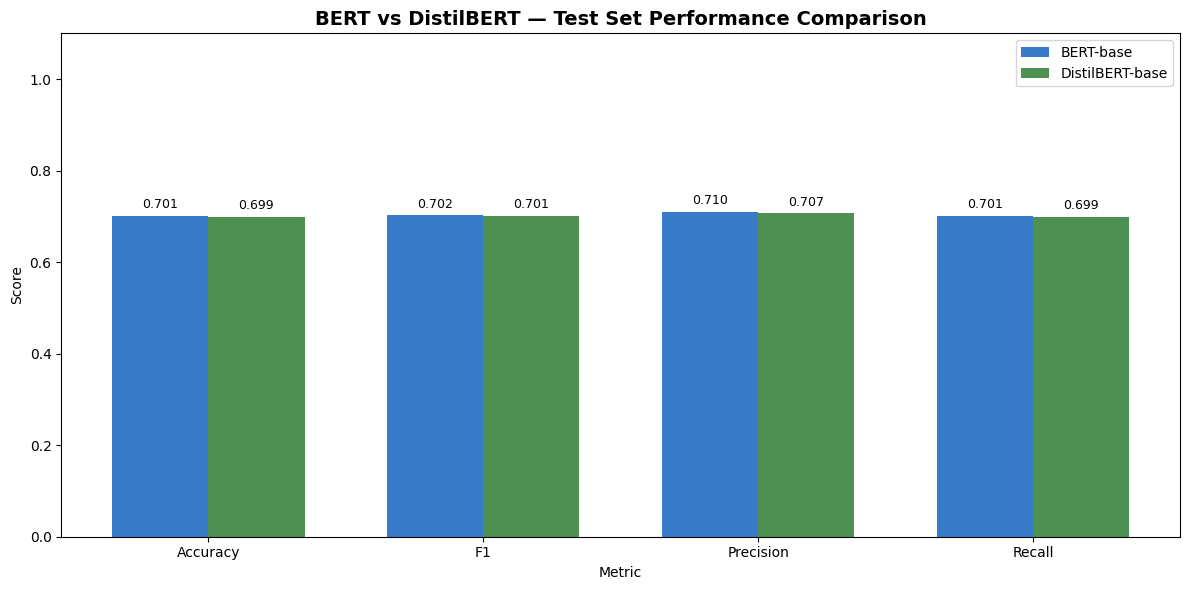

In [11]:
# ---- Visualization: Side-by-side metric comparison ----
metrics_list  = ['Accuracy', 'F1', 'Precision', 'Recall']
bert_vals     = [bert_test_metrics['accuracy'], bert_test_metrics['f1'],
                 bert_test_metrics['precision'], bert_test_metrics['recall']]
distilbert_vals = [db_test_metrics['accuracy'], db_test_metrics['f1'],
                   db_test_metrics['precision'], db_test_metrics['recall']]

x = np.arange(len(metrics_list))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, bert_vals,     width, label='BERT-base',       color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2, distilbert_vals, width, label='DistilBERT-base', color='#2E7D32', alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('BERT vs DistilBERT — Test Set Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.set_ylim(0, 1.1)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

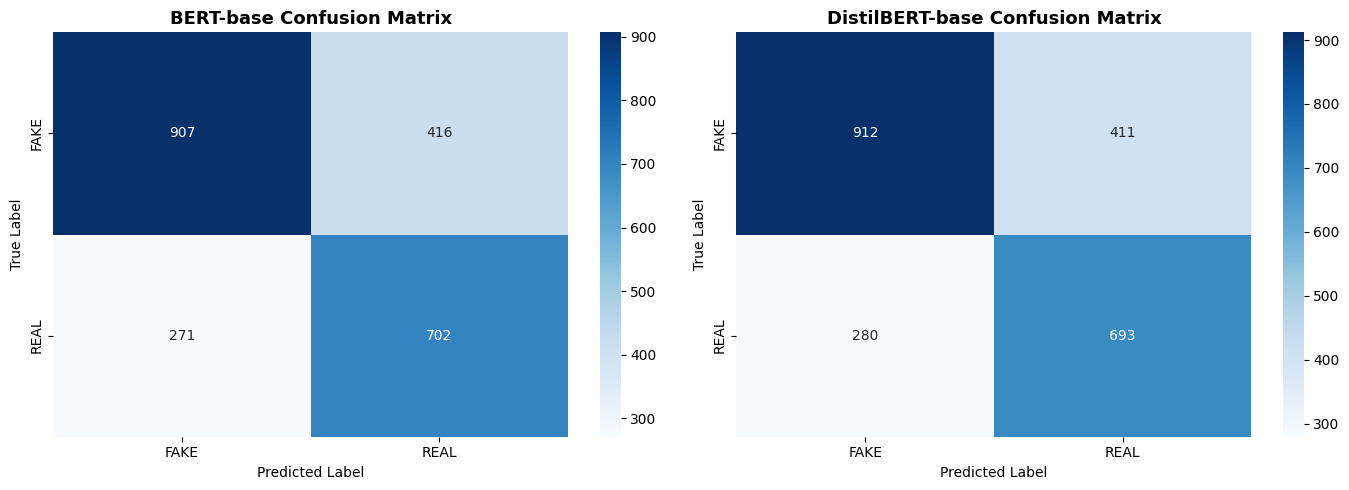

In [12]:
# ---- Confusion Matrices ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in zip(axes,
                          [bert_test_metrics['confusion'], db_test_metrics['confusion']],
                          ['BERT-base Confusion Matrix', 'DistilBERT-base Confusion Matrix']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

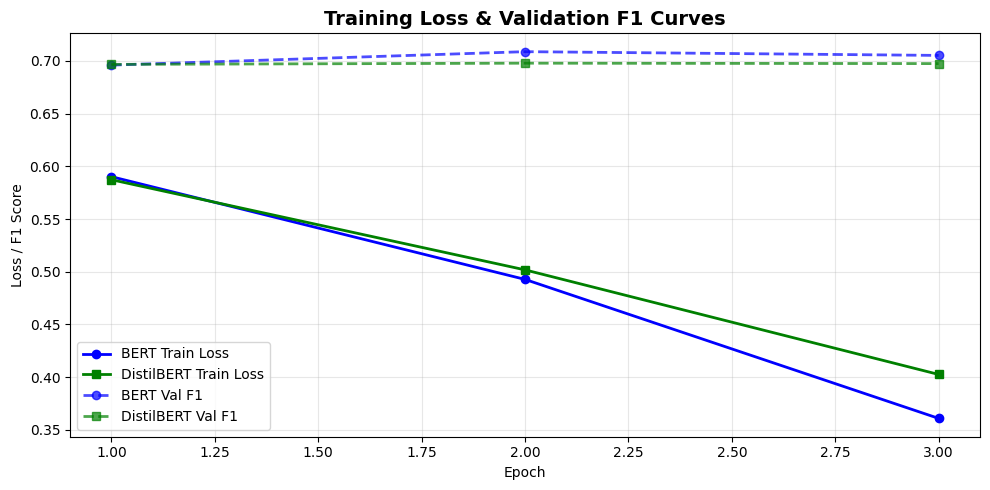


✅ Week 2 Complete! Proceed to Week3_Error_Analysis.ipynb


In [13]:
# ---- Training Loss Curves ----
fig, ax = plt.subplots(figsize=(10, 5))
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, bert_train_losses,   'b-o', label='BERT Train Loss',       linewidth=2)
ax.plot(epochs_range, db_train_losses,     'g-s', label='DistilBERT Train Loss', linewidth=2)
ax.plot(epochs_range, [m['f1'] for m in bert_val_metrics_per_epoch],
        'b--o', label='BERT Val F1', linewidth=2, alpha=0.7)
ax.plot(epochs_range, [m['f1'] for m in db_val_metrics_per_epoch],
        'g--s', label='DistilBERT Val F1', linewidth=2, alpha=0.7)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / F1 Score')
ax.set_title('Training Loss & Validation F1 Curves', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Week 2 Complete! Proceed to Week3_Error_Analysis.ipynb")

In [16]:
from sklearn.metrics import accuracy_score, f1_score

# Week 2 stored labels as bert_labels / db_labels (from evaluate())
bert_acc = accuracy_score(bert_labels, bert_preds)
bert_f1  = f1_score(bert_labels, bert_preds, average='weighted')
db_acc   = accuracy_score(db_labels, db_preds)
db_f1    = f1_score(db_labels, db_preds, average='weighted')

print(f"BERT       — Accuracy: {bert_acc:.4f} | F1: {bert_f1:.4f}")
print(f"DistilBERT — Accuracy: {db_acc:.4f} | F1: {db_f1:.4f}")

BERT       — Accuracy: 0.7008 | F1: 0.7025
DistilBERT — Accuracy: 0.6990 | F1: 0.7007


In [17]:
# ===== Week 3 setup — uses in-memory models & data from Week 2 =====
import numpy as np

# Map predictions back onto the test dataframe for analysis
test_df = test_df.reset_index(drop=True)
test_df['bert_pred']    = [id2label[p] for p in bert_preds]
test_df['db_pred']      = [id2label[p] for p in db_preds]
test_df['bert_correct'] = test_df['bert_pred'] == test_df['binary_label']
test_df['db_correct']   = test_df['db_pred']   == test_df['binary_label']

# label_names already defined from Week 2 (6-class LIAR2 order)
print("✅ Week 3 setup complete — ready for error analysis")
print(f"   Test samples: {len(test_df)}")
print(f"   BERT correct: {test_df['bert_correct'].sum()} / {len(test_df)}")
print(f"   DistilBERT correct: {test_df['db_correct'].sum()} / {len(test_df)}")

✅ Week 3 setup complete — ready for error analysis
   Test samples: 2296
   BERT correct: 1609 / 2296
   DistilBERT correct: 1605 / 2296


In [18]:
# Generate prediction confidences for Week 3 confidence analysis
import torch, numpy as np
from torch.utils.data import DataLoader

def get_confidences(model, dataset, device, batch_size=16):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    confs = []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            probs = torch.softmax(model(input_ids=ids, attention_mask=mask).logits, dim=1)
            confs.extend(torch.max(probs, dim=1).values.cpu().numpy())
    return confs

# Rebuild the test datasets (same as Week 2)
bert_test_ds = LIARDataset(test_df['statement'], test_df['binary_id'], bert_tokenizer)
db_test_ds   = LIARDataset(test_df['statement'], test_df['binary_id'], distilbert_tokenizer)

test_df['bert_confidence'] = get_confidences(bert_model, bert_test_ds, device)
test_df['db_confidence']   = get_confidences(distilbert_model, db_test_ds, device)

print("✅ Confidence scores added")
print(test_df[['bert_confidence', 'db_confidence']].describe())

✅ Confidence scores added
       bert_confidence  db_confidence
count      2296.000000    2296.000000
mean          0.846564       0.822478
std           0.141885       0.146032
min           0.500155       0.500488
25%           0.757325       0.711965
50%           0.893225       0.849903
75%           0.970724       0.964865
max           0.996431       0.996477


Error Analysis

In [22]:
# ===== Error rate by veracity class =====
bert_by_class = test_df.groupby('label_name')['bert_correct'].agg(total='count', correct='sum').reset_index()
bert_by_class['accuracy'] = bert_by_class['correct'] / bert_by_class['total']
bert_by_class['error_rate'] = 1 - bert_by_class['accuracy']

db_by_class = test_df.groupby('label_name')['db_correct'].agg(total='count', correct='sum').reset_index()
db_by_class['accuracy'] = db_by_class['correct'] / db_by_class['total']
db_by_class['error_rate'] = 1 - db_by_class['accuracy']

print("BERT — accuracy per veracity class:")
print(bert_by_class[['label_name', 'total', 'correct', 'accuracy']].to_string(index=False))
print("\nDistilBERT — accuracy per veracity class:")
print(db_by_class[['label_name', 'total', 'correct', 'accuracy']].to_string(index=False))

BERT — accuracy per veracity class:
 label_name  total  correct  accuracy
barely-true    360      160  0.444444
      false    660      487  0.737879
  half-true    371      252  0.679245
mostly-true    343      248  0.723032
 pants-fire    303      260  0.858086
       true    259      202  0.779923

DistilBERT — accuracy per veracity class:
 label_name  total  correct  accuracy
barely-true    360      174  0.483333
      false    660      482  0.730303
  half-true    371      254  0.684636
mostly-true    343      251  0.731778
 pants-fire    303      256  0.844884
       true    259      188  0.725869


In [23]:
label_names_6 = label_names

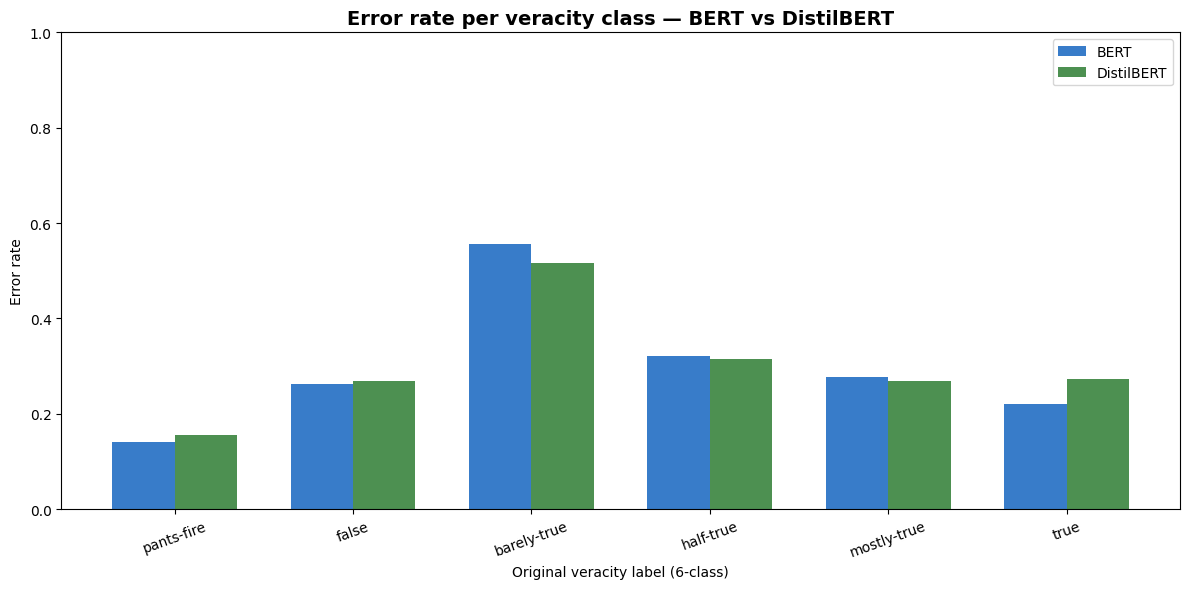

In [24]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(label_names))
width = 0.35

bert_err = [bert_by_class.loc[bert_by_class['label_name']==l, 'error_rate'].values[0]
            if l in bert_by_class['label_name'].values else 0 for l in label_names]
db_err   = [db_by_class.loc[db_by_class['label_name']==l, 'error_rate'].values[0]
            if l in db_by_class['label_name'].values else 0 for l in label_names]

ax.bar(x - width/2, bert_err, width, label='BERT', color='#1565C0', alpha=0.85)
ax.bar(x + width/2, db_err,   width, label='DistilBERT', color='#2E7D32', alpha=0.85)
ax.set_xlabel('Original veracity label (6-class)')
ax.set_ylabel('Error rate')
ax.set_title('Error rate per veracity class — BERT vs DistilBERT', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(label_names, rotation=20)
ax.legend(); ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig('error_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

Confidence analysis

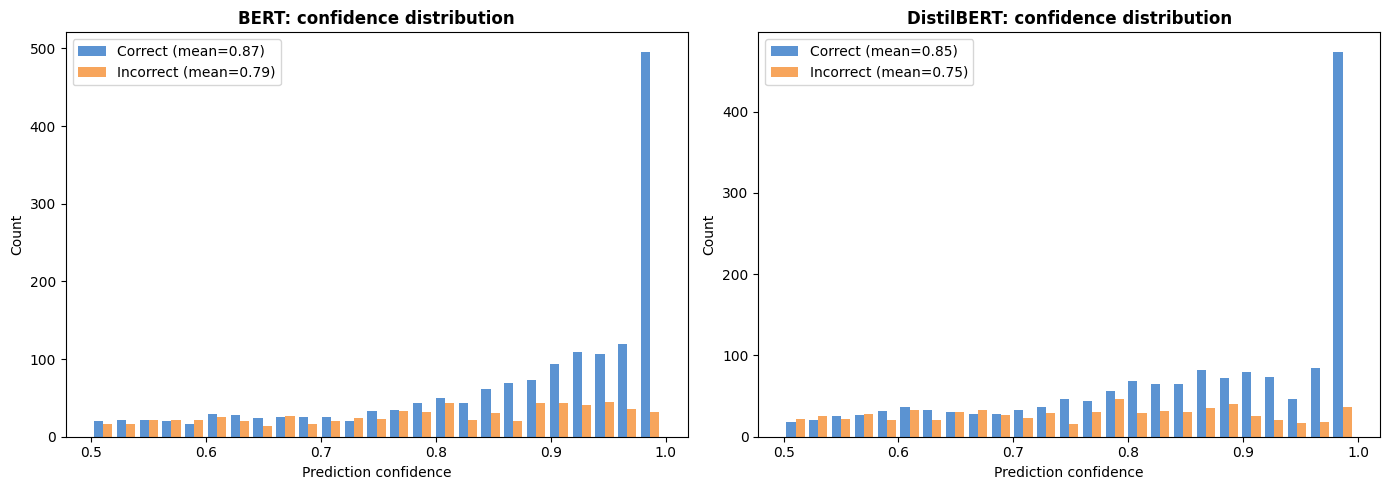

BERT       — correct mean conf: 0.873 | incorrect: 0.785
DistilBERT — correct mean conf: 0.852 | incorrect: 0.755


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, conf_col, correct_col, title in zip(
    axes, ['bert_confidence', 'db_confidence'], ['bert_correct', 'db_correct'], ['BERT', 'DistilBERT']
):
    correct_conf   = test_df[test_df[correct_col] == True][conf_col]
    incorrect_conf = test_df[test_df[correct_col] == False][conf_col]
    ax.hist([correct_conf, incorrect_conf], bins=25,
            label=[f'Correct (mean={correct_conf.mean():.2f})',
                   f'Incorrect (mean={incorrect_conf.mean():.2f})'],
            color=['#1565C0', '#F57F17'], alpha=0.7)
    ax.set_title(f'{title}: confidence distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prediction confidence'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout()
plt.savefig('confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"BERT       — correct mean conf: {test_df[test_df['bert_correct']]['bert_confidence'].mean():.3f} | incorrect: {test_df[~test_df['bert_correct']]['bert_confidence'].mean():.3f}")
print(f"DistilBERT — correct mean conf: {test_df[test_df['db_correct']]['db_confidence'].mean():.3f} | incorrect: {test_df[~test_df['db_correct']]['db_confidence'].mean():.3f}")

In [26]:
bert_errors = test_df[test_df['bert_correct'] == False][
    ['statement', 'label_name', 'binary_label', 'bert_pred', 'bert_confidence']
]

print("=" * 70)
print("BERT MISCLASSIFICATIONS — sample of 8")
print("=" * 70)
for _, row in bert_errors.sample(min(8, len(bert_errors)), random_state=42).iterrows():
    print(f"\nStatement: {row['statement'][:110]}")
    print(f"  True: {row['label_name']} → {row['binary_label']}  |  Predicted: {row['bert_pred']} (conf {row['bert_confidence']:.2f})")

BERT MISCLASSIFICATIONS — sample of 8

Statement: Says Joe Manchin displayed an "unwillingness to change the failed Obamacare.
  True: half-true → REAL  |  Predicted: FAKE (conf 0.96)

Statement: One out of every three students currently today is ready for college before they go there.
  True: false → FAKE  |  Predicted: REAL (conf 0.93)

Statement: Former President Barack Obama "removed 500,000 pedophiles from background check database.
  True: false → FAKE  |  Predicted: REAL (conf 0.70)

Statement: During the Reagan administration, "Millions of people were thrown out of work.
  True: barely-true → FAKE  |  Predicted: REAL (conf 0.66)

Statement: The Georgia Lottery Corp. has only once in the past 16 years paid out the agreed upon 35 percent of proceeds t
  True: false → FAKE  |  Predicted: REAL (conf 0.62)

Statement: There were 36 states where Republicans who were in charge refused to implement a state (health insurance) exch
  True: barely-true → FAKE  |  Predicted: REAL (conf 0.9

 agreement analysis

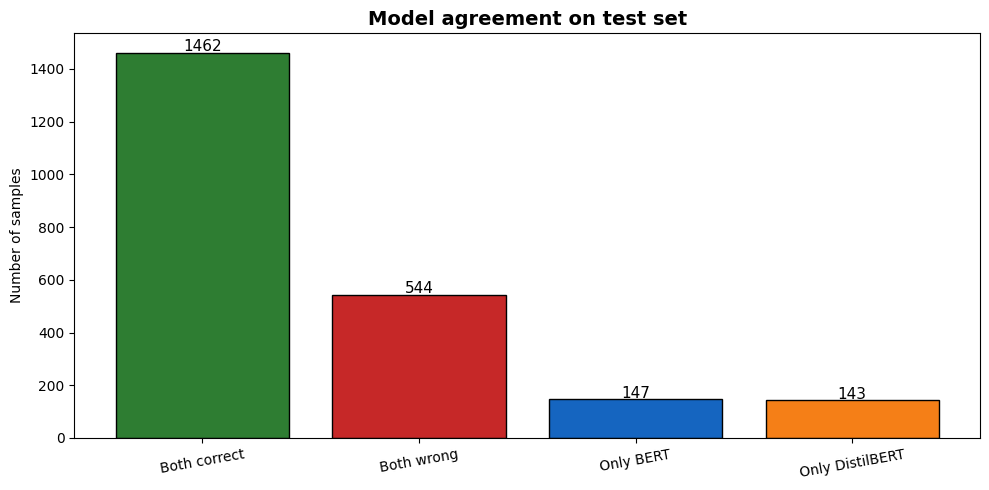

Both agree (correct or wrong): 2006 / 2296
Hardest cases — both models wrong: 544


In [27]:
import matplotlib.pyplot as plt

test_df['both_correct'] = test_df['bert_correct'] & test_df['db_correct']
test_df['both_wrong']   = ~test_df['bert_correct'] & ~test_df['db_correct']
test_df['bert_only']    = test_df['bert_correct'] & ~test_df['db_correct']
test_df['db_only']      = ~test_df['bert_correct'] & test_df['db_correct']

counts = {
    'Both correct':      test_df['both_correct'].sum(),
    'Both wrong':        test_df['both_wrong'].sum(),
    'Only BERT':         test_df['bert_only'].sum(),
    'Only DistilBERT':   test_df['db_only'].sum(),
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.keys(), counts.values(),
              color=['#2E7D32', '#C62828', '#1565C0', '#F57F17'], edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=11)
ax.set_title('Model agreement on test set', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of samples')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('agreement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Both agree (correct or wrong): {test_df['both_correct'].sum() + test_df['both_wrong'].sum()} / {len(test_df)}")
print(f"Hardest cases — both models wrong: {test_df['both_wrong'].sum()}")